In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum()
print(grouped_df)

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64


Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

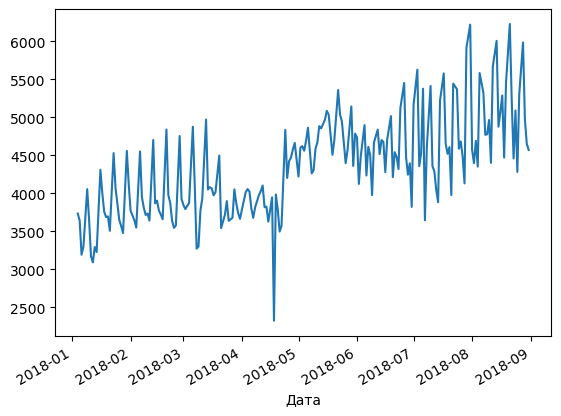

In [7]:
grouped_df.plot()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

График сильно варьируется в каждом месяце, минимыльные и максимальные точки в каждом месяце примерно расходятся на 1000. В апреле наблюдается сильный упадок но поправляется в следующем месяце. В целом тренд расчет верх, минимальные значения последнего месяца больше максимального значения первого месяца. 

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
max_row_index = df['Количество'].idxmax()

print(df.loc[max_row_index])

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
summer_3_warehouse = df[
(df['Склад']==3) &
(df['Дата'].dt.month.isin([6,7,8]))
].copy()

In [10]:
summer_3_warehouse['День недели'] = summer_3_warehouse['Дата'].dt.weekday

In [11]:
wednesdays = summer_3_warehouse[summer_3_warehouse['День недели']==2]

In [12]:
top_product = wednesdays.groupby('Номенклатура')['Количество'].sum()

In [13]:
print(top_product.sort_values(ascending=False).head(1))

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [14]:
print(grouped_df.index.min())
print(grouped_df.index.max())

2018-01-04 00:00:00
2018-08-31 00:00:00


In [15]:
weather_df = pd.read_excel('weather.xls', skiprows=6).copy()
print(weather_df.head())

  Местное время в Астане     T     Po      P   Pa     U  \
0       31.08.2018 23:00   8.2  736.6  768.3  0.2  78.0   
1       31.08.2018 20:00   9.6  736.4  767.9  1.2  88.0   
2       31.08.2018 17:00  11.3  735.2  766.4  0.4  83.0   
3       31.08.2018 14:00  12.3  734.8  765.9  0.9  80.0   
4       31.08.2018 11:00  13.2  733.9  764.8  1.0  83.0   

                                       DD  Ff  ff10  ff3  ...  \
0          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
1    Ветер, дующий с западо-северо-запада   3   NaN  NaN  ...   
2  Ветер, дующий с востоко-северо-востока   4   NaN  NaN  ...   
3          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
4   Ветер, дующий с северо-северо-востока   4   NaN  NaN  ...   

                                                  Cm  \
0  Высококучевых, высокослоистых или слоисто-дожд...   
1  Высококучевых, высокослоистых или слоисто-дожд...   
2                                                NaN   
3                             

In [16]:
weather_df = weather_df.iloc[:,[0,1]]
weather_df.columns = ['Date_time','T']
print(weather_df.head())

          Date_time     T
0  31.08.2018 23:00   8.2
1  31.08.2018 20:00   9.6
2  31.08.2018 17:00  11.3
3  31.08.2018 14:00  12.3
4  31.08.2018 11:00  13.2


In [17]:
weather_df['Date_time'] = pd.to_datetime(weather_df['Date_time'], dayfirst = True).dt.date

weather_df['Date_time'] = pd.to_datetime(weather_df['Date_time'])

weather_df_avg = weather_df.groupby('Date_time')['T'].mean().reset_index()

print(weather_df_avg)

     Date_time        T
0   2018-01-04 -14.0750
1   2018-01-05 -16.8625
2   2018-01-06 -13.3000
3   2018-01-07 -12.7500
4   2018-01-08 -15.4125
..         ...      ...
235 2018-08-27  12.5250
236 2018-08-28  14.1125
237 2018-08-29  13.8250
238 2018-08-30  14.1750
239 2018-08-31  11.0250

[240 rows x 2 columns]


In [18]:
sales_final = grouped_df.reset_index().copy()

print(sales_final.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


In [19]:
sales_final.columns = ['Date_time', 'Sales']

print(sales_final.head())

   Date_time  Sales
0 2018-01-04   3734
1 2018-01-05   3643
2 2018-01-06   3193
3 2018-01-07   3298
4 2018-01-09   4055


In [20]:
sales_final['Date_time'] = pd.to_datetime(sales_final['Date_time'])
weather_df_avg['Date_time'] = pd.to_datetime(weather_df_avg['Date_time'])

In [21]:
df_merged = pd.merge(sales_final, weather_df_avg, on='Date_time', how='inner')

In [22]:
df_merged.set_index('Date_time', inplace=True)

In [23]:
print(df_merged.head())

            Sales        T
Date_time                 
2018-01-04   3734 -14.0750
2018-01-05   3643 -16.8625
2018-01-06   3193 -13.3000
2018-01-07   3298 -12.7500
2018-01-09   4055  -6.2500


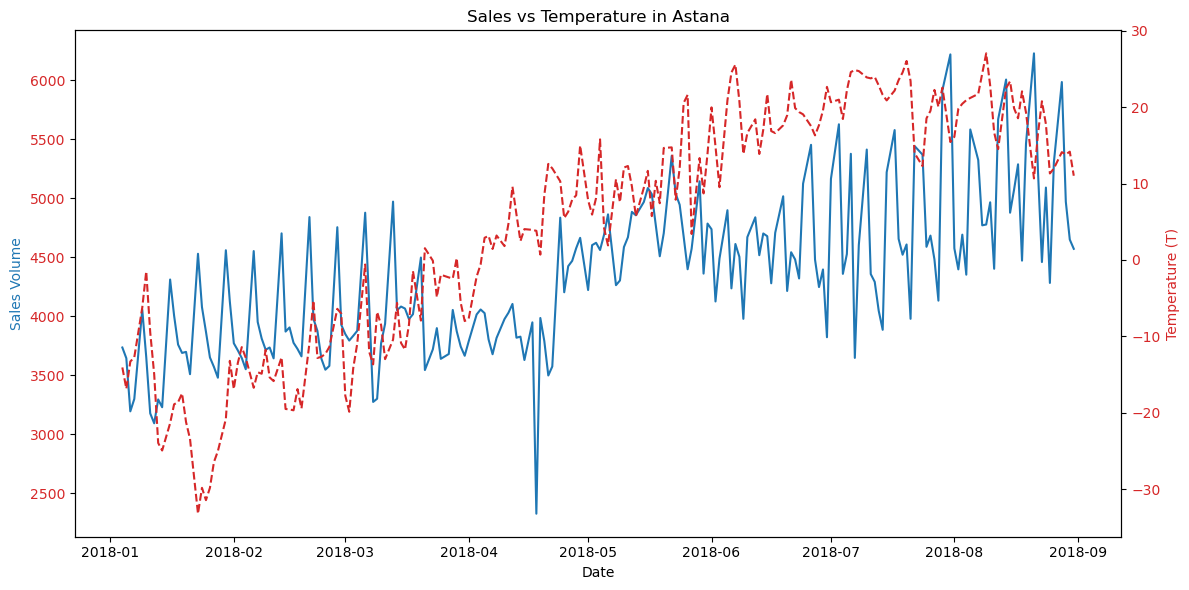

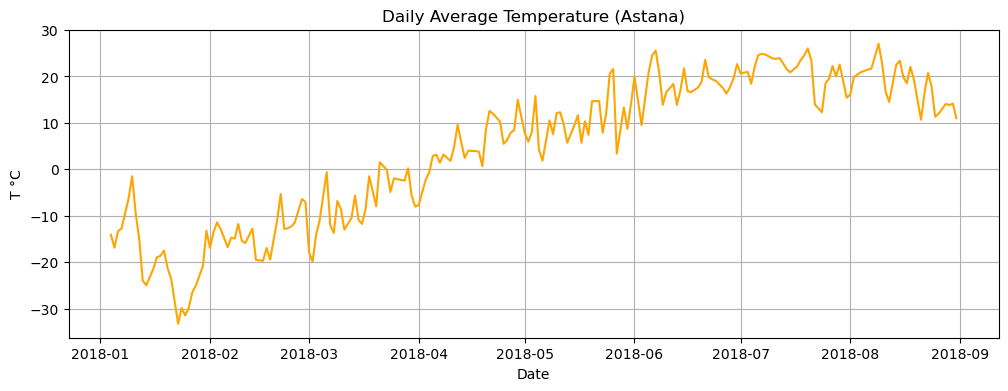

In [26]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Sales Volume', color='tab:blue')
ax1.plot(df_merged.index, df_merged['Sales'], color='tab:blue', label='Sales')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx() 
ax2.set_ylabel('Temperature (T)', color='tab:red')
ax2.plot(df_merged.index, df_merged['T'], color='tab:red', linestyle='--', label='Temperature')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Sales vs Temperature in Astana')
fig.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_merged.index, df_merged['T'], color='orange')
plt.title('Daily Average Temperature (Astana)')
plt.xlabel('Date')
plt.ylabel('T °C')
plt.grid(True)
plt.show()